In [5]:
import os
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "DeepUnitMatch"))
sys.path = list(set(sys.path))
from testing.test import *
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import seaborn as sns


def paired_violin_plot(
    M,
    labels=None,
    colors=None,
    ylabel="Value",
    figsize=(3, 5),
    jitter=0.06,
    violin_width=0.6,
    show_violin=True,
    show_points=True,
    show_mean=True,
    show_sem=True,
    alpha_lines=0.35,
    comparisons="adjacent",   # "adjacent", "all", or list of tuples
    ax=None,
):
    """
    Parameters
    ----------
    M : ndarray
        Shape = (n_models, n_samples)

    labels : list of str
        Labels for each model.

    colors : list
        List of matplotlib colours.

    comparisons :
        "adjacent" -> compare neighbouring models
        "all" -> compare every pair
        [(0,2),(1,3)] -> custom comparisons
    """

    M = np.asarray(M)

    if M.ndim != 2:
        raise ValueError("M must have shape (n_models, n_samples).")

    n_models, n_samples = M.shape

    if labels is None:
        labels = [f"Model {i+1}" for i in range(n_models)]

    if colors is None:
        default_palette = sns.color_palette("tab10", 10)

        def model_color(name):
            name = str(name)

            if "DeepUnitMatch" in name:
                return "#ff0000"  # red
            if "DUM" in name or "DeepUM" in name or "exclude" in name or "n_output" in name:
                return "#fc8d8d"  # light red
            if name == "UMPy":
                return "#001aff"  # blue
            if "UMPy" in name and name != "UMPy":
                return "#7c90ff"  # lighter blue
            if "DANT" in name:
                return "#7546ce"  # purple
            if "DANT_no_functional" in name:
                return "#ba95ff"  # light purple
            if "EMD" in name:
                return "#2ca02c"  # green
            return default_palette[0]

        colors = [model_color(label) for label in labels]

    x = np.arange(n_models)
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    # ---------------------------------------------------
    # Violin plots
    # ---------------------------------------------------
    if show_violin:
        vp = ax.violinplot(
            M.T,
            positions=x,
            widths=violin_width,
            showmeans=False,
            showmedians=False,
            showextrema=False
        )

        for body, colour in zip(vp["bodies"], colors):
            body.set_facecolor(colour)
            body.set_edgecolor("none")
            body.set_alpha(0.25)

    # ---------------------------------------------------
    # Connecting lines
    # ---------------------------------------------------
    for i in range(n_samples):
        xx = x + np.random.uniform(-jitter/3, jitter/3, n_models)
        ax.plot(xx, M[:, i],
                color="0.75",
                lw=1,
                alpha=alpha_lines,
                zorder=1)

    # ---------------------------------------------------
    # Scatter points
    # ---------------------------------------------------
    if show_points:
        for k in range(n_models):
            xx = x[k] + np.random.uniform(-jitter, jitter, n_samples)

            ax.scatter(
                xx,
                M[k],
                s=35,
                color=colors[k],
                edgecolor="none",
                zorder=3
            )

    # ---------------------------------------------------
    # Mean ± SEM
    # ---------------------------------------------------
    means = np.nanmean(M, axis=1)
    sem = np.nanstd(M, axis=1, ddof=1) / np.sqrt(n_samples)

    if show_sem:
        ax.errorbar(
            x,
            means,
            yerr=sem,
            fmt="none",
            color="black",
            lw=2,
            zorder=4
        )

    if show_mean:
        ax.scatter(
            x,
            means,
            s=70,
            facecolor="white",
            edgecolor="black",
            linewidth=2,
            zorder=5
        )

    # ---------------------------------------------------
    # Significance tests
    # ---------------------------------------------------
    if comparisons is not None:
        if comparisons == "adjacent":
            comparisons = [(i, i + 1) for i in range(n_models - 1)]

        elif comparisons == "all":
            comparisons = [
                (i, j)
                for i in range(n_models)
                for j in range(i + 1, n_models)
            ]

        elif isinstance(comparisons, (int, np.integer)):
            ref = int(comparisons)
            if not 0 <= ref < n_models:
                raise ValueError(f"comparison model index {ref} is out of range for {n_models} models.")
            comparisons = [(ref, j) for j in range(n_models) if j != ref]

        elif isinstance(comparisons, tuple) and len(comparisons) == 2:
            ref, targets = comparisons
            ref = int(ref)
            if not 0 <= ref < n_models:
                raise ValueError(f"comparison model index {ref} is out of range for {n_models} models.")

            if isinstance(targets, (int, np.integer)):
                targets = [int(targets)]
            else:
                targets = list(targets)

            comparisons = [(ref, j) for j in targets if j != ref]

        elif isinstance(comparisons, (list, tuple, np.ndarray)) and len(comparisons) > 0:
            comparisons = list(comparisons)
        else:
            comparisons = []

        if len(comparisons) > 0:
            ymax = np.nanmax(M)
            yrange = np.nanmax(M) - np.nanmin(M)

            if yrange == 0:
                yrange = 1

            h = 0.05 * yrange
            base = ymax + 0.05 * yrange

            for k, (i, j) in enumerate(comparisons):
                p = wilcoxon(M[i], M[j], nan_policy="omit").pvalue
                y = base + k * (2 * h)

                if p < 0.05:
                    ax.plot(
                        [i, i, j, j],
                        [y, y + h, y + h, y],
                        color="black",
                        lw=1.5
                    )

                    ax.text(
                        (i + j) / 2,
                        y + h,
                        f"p = {p:.3g}",
                        ha="center",
                        va="bottom",
                        fontsize=9,
                        style="italic"
                    )

    # ---------------------------------------------------
    # Formatting
    # ---------------------------------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    ax.set_ylabel(ylabel)

    sns.despine()
    ax.set_xlim(-0.5, n_models - 0.5)
    ax.set_ylim(bottom=0)

    if ax is None:
        plt.tight_layout()

    return fig, ax


In [7]:
# Figure export -- same FIGURES_DIR/savefig_with_svg convention as
# figure1.ipynb/figure2.ipynb and plot_auc_summary.py: every figure gets
# saved as PNG (for quick viewing) plus an SVG alongside it (editable in
# Inkscape/Illustrator for the paper).
FIGURES_DIR = r"\\znas.cortexlab.net\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData\figures"
fig_dir = os.path.join(FIGURES_DIR, "ModelComparison")
os.makedirs(fig_dir, exist_ok=True)


def savefig_with_svg(fig, out_path, **kwargs):
    """Save out_path (a .png path) plus an editable .svg copy alongside it (e.g. for Inkscape)."""
    fig.savefig(out_path, **kwargs)
    fig.savefig(os.path.splitext(out_path)[0] + ".svg", **{k: v for k, v in kwargs.items() if k != "dpi"})

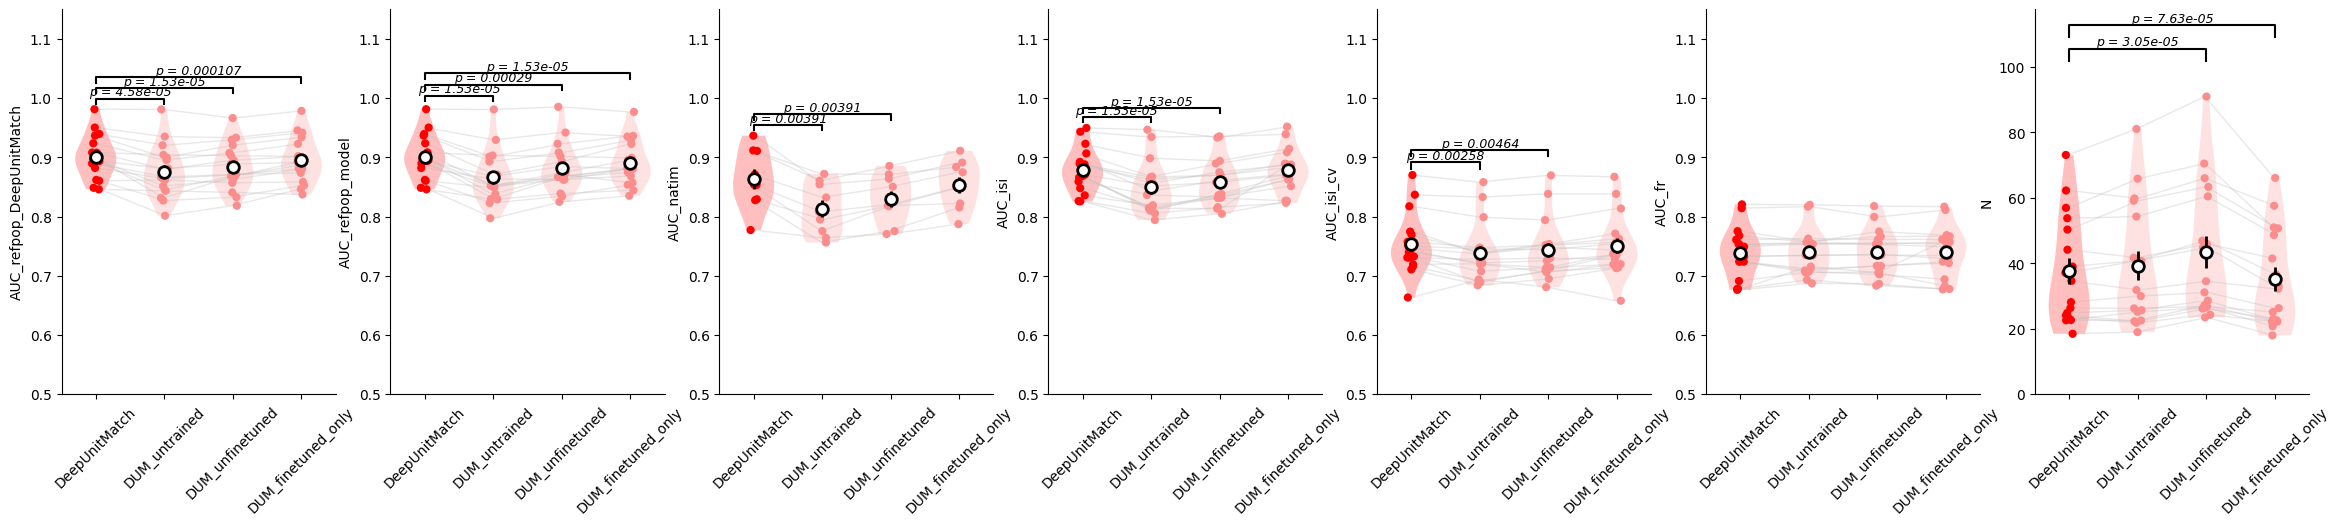

In [8]:
RESULTS_DIR = r"\\znas.cortexlab.net\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData\results"
# RESULTS_DIR = r"\\znas.cortexlab.net\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData\results\N_set_by_UMPy"
# RESULTS_DIR = r"\\znas.cortexlab.net\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData\results\N_set_by_DANT"
# RESULTS_DIR = r"\\znas.cortexlab.net\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData\results\N_set_by_DeepUnitMatch"

models = [
          "DeepUnitMatch",
        #   "UMPy", 
        #   "EMD", 
        #   "DANT", 
        #   "DANT_no_functional",
        #   "DUM_maxdist=20", "DUM_maxdist=50", "DUM_maxdist=100", "DUM_maxdist=inf", 
        #   "UMPy_maxdist=20", "UMPy_maxdist=50", "UMPy_maxdist=100", "UMPy_maxdist=inf",
        #   "DUM_W_ij=1","DUM_W_ij=5","DUM_W_ij=10","DUM_W_ij=15","DUM_W_ij=20", 
        #   "n_output=8_after_ae_and_finetune", "n_output=32_after_ae_and_finetune", "n_output=128_after_ae_and_finetune", "n_output=256_after_ae_and_finetune", 
          "DUM_untrained", "DUM_unfinetuned", "DUM_finetuned_only",
          # "exclude_mice_m1_1_after_ae_and_finetune", "exclude_mice_m1_2_after_ae_and_finetune", "exclude_mice_m1_3_after_ae_and_finetune",
          # "exclude_mice_m6_1_after_ae_and_finetune", "exclude_mice_m6_2_after_ae_and_finetune", "exclude_mice_m6_3_after_ae_and_finetune",
          # "exclude_mice_m12_1_after_ae_and_finetune", "exclude_mice_m12_2_after_ae_and_finetune", "exclude_mice_m12_3_after_ae_and_finetune",
            ]


shared_columns = ["mouse", "probe", "loc", "day1", "day2", "r1", "r2", "delta_days"]
def rename_df_col(df, shared_columns, model):
    return df.rename(columns={col: f"{col}_{model}" for col in df.columns if col not in shared_columns})

# read, rename, and index each model dataframe
dfs = []
for model in models:
    dfm = (
        pd.read_csv(os.path.join(RESULTS_DIR, f"UM Probabilities_{model}_results.csv"))
          .drop_duplicates()
          .reset_index(drop=True)
    )
    dfm = rename_df_col(dfm, shared_columns, model)
    dfm = dfm.set_index(shared_columns)
    dfs.append(dfm)

# keep only rows present in all files (use join='outer' to keep union)
merged = pd.concat(dfs, axis=1, join="inner")

# compute keep: True if any model has N>19
n_cols = [f"N_{m}" for m in models]
keep = merged[n_cols].gt(19).any(axis=1)

# filter and restore columns/index
merged = merged[keep].reset_index()

metrics_to_plot = ['AUC_refpop_DeepUnitMatch', 'AUC_refpop_model', 'AUC_natim', 'AUC_isi', 'AUC_isi_cv', 'AUC_fr', 'N']
# metrics_to_plot = ['AUC_isi', 'AUC_isi_KL', 'AUC_isi_Wassertstein', 'N']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=[1+4*len(metrics_to_plot), 5])
for idx, metric_to_plot in enumerate(metrics_to_plot):

    # REPLACE NANS WITH 0.5
    AUC_columns = [f"{metric_to_plot}_{model}" for model in models]
    merged_cut = merged[~np.all(np.isnan(merged[AUC_columns]), axis=1)]
    merged_cut = merged_cut.fillna(0.5) # remaining AUCs set to 0.5

    M = []
    for model in models:
        avg_metric_by_mouse = merged_cut.groupby("mouse")[f"{metric_to_plot}_{model}"].mean()
        if metric_to_plot in ['AUC_fr', 'AUC_isi_cv', 'AUC_isi_KL', 'AUC_isi_Wassertstein']:
            avg_metric_by_mouse = 1-avg_metric_by_mouse
        M.append(avg_metric_by_mouse.values)

    M = np.asarray(M)
    M = M[:, ~np.all(np.isnan(M), axis=0)]
    fig, ax = paired_violin_plot(
        M,
        labels=models,
        ylabel=metric_to_plot,
        comparisons=0,   # or "all" or [(0,3), (1,4)]
        show_violin = True,
        colors = None,
        ax=axes[idx]
    )
    if metric_to_plot != 'N':
        ax.set_ylim(bottom=0.5, top=1.15)

savefig_with_svg(fig, os.path.join(fig_dir, "model_comparison_AUC_summary.png"), dpi=300, bbox_inches="tight")

In [ ]:
merged_cut = merged_cut[merged_cut['mouse'] == 'AL032']

In [12]:
merged[merged['N_DUM_untrained'] != merged['N_DUM_unfinetuned']]

,mouse,probe,loc,day1,day2,r1,r2,delta_days,AUC_isi_DUM_untrained,AUC_isi_KL_DUM_untrained,...,AUC_isi_DUM_finetuned_only,AUC_isi_KL_DUM_finetuned_only,AUC_isi_Wassertstein_DUM_finetuned_only,AUC_fr_DUM_finetuned_only,AUC_isi_cv_DUM_finetuned_only,AUC_refpop_UMPy_DUM_finetuned_only,AUC_refpop_DeepUnitMatch_DUM_finetuned_only,AUC_refpop_model_DUM_finetuned_only,AUC_natim_DUM_finetuned_only,N_DUM_finetuned_only
419,AL032,19011111882,2,0,4,1.0,3.0,4,0.868524,0.126452,...,0.889038,0.113764,0.173414,0.358436,0.251201,NaN,0.901048,0.820315,NaN,52
420,AL032,19011111882,2,0,12,1.0,4.0,12,0.798567,0.159989,...,0.883893,0.100972,0.134633,0.399748,0.331766,NaN,0.709965,0.731672,NaN,20
421,AL032,19011111882,2,0,13,1.0,5.0,13,0.804556,0.186671,...,0.924451,0.066158,0.135105,0.372198,0.305681,NaN,0.810184,0.683627,NaN,12
422,AL032,19011111882,2,0,24,1.0,6.0,24,0.764691,0.177798,...,0.836841,0.184871,0.113408,0.330113,0.405391,NaN,0.666382,0.560159,NaN,8
423,AL032,19011111882,2,0,25,1.0,7.0,25,0.722864,0.229382,...,0.773342,0.219022,0.307679,0.428469,0.395736,NaN,0.755821,0.830747,NaN,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,AL032,19011111882,2,143,207,18.0,20.0,64,0.793194,0.232400,...,0.879172,0.156758,0.180587,0.388881,0.215703,NaN,0.925339,0.921527,0.724930,46
609,AL032,19011111882,2,143,235,18.0,21.0,92,0.694964,0.348609,...,0.665462,0.417599,0.155287,0.514361,0.277857,NaN,0.690338,0.732604,0.443149,4
610,AL032,19011111882,2,188,207,19.0,20.0,19,0.752418,0.229175,...,0.767982,0.193333,0.252228,0.365037,0.446768,NaN,0.840235,0.834442,NaN,66
611,AL032,19011111882,2,188,235,19.0,21.0,47,0.674463,0.290472,...,0.507912,0.352588,0.568981,0.314112,0.190971,NaN,0.768217,0.654173,NaN,5


In [31]:
df1 = (
    pd.read_csv(os.path.join(RESULTS_DIR, f"UM Probabilities_{models[0]}_results.csv"))
        .drop_duplicates()
        .reset_index(drop=True)
)

df2 = (
    pd.read_csv(os.path.join(RESULTS_DIR, f"UM Probabilities_{models[1]}_results.csv"))
        .drop_duplicates()
        .reset_index(drop=True)
)


df3 = (
    pd.read_csv(r"\\znas.cortexlab.net\Lab\Share\UNITMATCHTABLES_ENNY_CELIAN_JULIE\DeepUM_NatMeth2026_V3_OnMergedData\results\UM Probabilities_UMPy_results.csv")
        .drop_duplicates()
        .reset_index(drop=True)
)

In [33]:
print(df1[(df1['mouse'] == 'AL032') & (df1['loc'] == '2') & (df1['r1'] == 1) & (df1['r2'] == 3)]['N'])
print(df2[(df2['mouse'] == 'AL032') & (df2['loc'] == '2') & (df2['r1'] == 1) & (df2['r2'] == 3)]['N'])
print(df3[(df3['mouse'] == 'AL032') & (df3['loc'] == '2') & (df3['r1'] == 1) & (df3['r2'] == 3)]['N'])

15410    17
Name: N, dtype: int64
14169    88
Name: N, dtype: int64
14169    17
Name: N, dtype: int64


In [ ]:
# -- Untrained vs trained, restricted to close pairs only ------------------
# Targeted check for just this comparison: does the untrained-vs-trained AUC
# gap widen once "trivially far apart, no model would ever call this a
# match" pairs are excluded? Reuses plot_auc_vs_delta_days.py's
# collect_binned_pairs() directly against each dataset's own MatchTable.csv
# (already on disk for these baseline models from
# run_deepunitmatch_batch_onMerged_baselines.py) -- deliberately NOT
# fast_testing.py/matchtables_algo.db, since that database doesn't have
# DUM_untrained/DUM_unfinetuned/DUM_finetuned_only merged in at all (would
# need a full 171-location re-merge + re-run just to get them there).
# restrict_to_max_dist restricts every score's AUC to dist_col > 0 (this
# run's own max_dist), not just ISI_correlations -- see that parameter's
# docstring. This gives per-DATASET AUC (pooled across a dataset's session
# pairs), coarser than this notebook's usual per-session-pair figures, but
# fast: models_to_include below makes collect_binned_pairs() skip every
# other model's MatchTable.csv entirely.
import sys
sys.path.insert(0, os.getcwd())
import plot_auc_vs_delta_days as dvd

UNTRAINED_COMPARISON_MODELS = {"DeepUnitMatch", "DUM_untrained", "DUM_unfinetuned", "DUM_finetuned_only"}

session_date_lookup = dvd.get_session_date_lookup()


def get_dataset_level_auc(restrict_to_max_dist):
    (_, _, _, _, dataset_level_auc_rows, _, _, _) = dvd.collect_binned_pairs(
        session_date_lookup,
        models_to_include=UNTRAINED_COMPARISON_MODELS,
        restrict_to_max_dist=restrict_to_max_dist,
    )
    out = pd.DataFrame(dataset_level_auc_rows)
    out["max_dist_restricted"] = restrict_to_max_dist
    return out


auc_maxdist_compare = pd.concat(
    [get_dataset_level_auc(False), get_dataset_level_auc(True)], ignore_index=True
)
auc_maxdist_compare.to_csv(
    os.path.join(dvd.BASE_OUTPUT, "untrained_vs_trained_maxdist_compare.csv"), index=False
)
auc_maxdist_compare.head()

In [ ]:
# For each score and model, plot "all pairs" next to "<max_dist only" so the
# adjacent-pair significance bracket in paired_violin_plot lands exactly on
# the comparison that matters (restricted vs unrestricted for the same
# model), not between different models.
models_order = ["DUM_untrained", "DUM_unfinetuned", "DUM_finetuned_only", "DeepUnitMatch"]
scores_present = sorted(auc_maxdist_compare["score"].unique())

fig, axes = plt.subplots(1, len(scores_present), figsize=[1 + 4 * len(scores_present), 5])
if len(scores_present) == 1:
    axes = [axes]

for idx, score in enumerate(scores_present):
    sub = auc_maxdist_compare[auc_maxdist_compare["score"] == score]

    # mouse x (model, restricted) grid, so every column has one row per mouse
    # in the same order -- missing cells (e.g. a mouse with zero valid pairs
    # for a restricted model/score) filled with 0.5 (chance), same convention
    # as this notebook's other AUC panels (see the "REPLACE NANS WITH 0.5"
    # cell above).
    pivot = sub.pivot_table(index="mouse", columns=["model", "max_dist_restricted"], values="value", aggfunc="mean")

    labels, M = [], []
    for model in models_order:
        for restricted, tag in [(False, "all pairs"), (True, "<max_dist")]:
            col = (model, restricted)
            vals = pivot[col] if col in pivot.columns else pd.Series(np.nan, index=pivot.index)
            labels.append(f"{model}\n{tag}")
            M.append(vals.fillna(0.5).to_numpy())

    M = np.asarray(M)
    paired_violin_plot(
        M,
        labels=labels,
        ylabel=score,
        comparisons="adjacent",
        show_violin=True,
        colors=None,
        ax=axes[idx],
    )
    axes[idx].set_ylim(bottom=0.5, top=1.15)

fig.tight_layout()
savefig_with_svg(fig, os.path.join(fig_dir, "model_comparison_maxdist_restriction.png"), dpi=300, bbox_inches="tight")